# Выбор локации для скважины

Допустим, вы работаете в добывающей компании «ГлавРосГосНефть». Нужно решить, где бурить новую скважину.

Вам предоставлены пробы нефти в трёх регионах: в каждом 100 000 месторождений, где измерили качество нефти и объём её запасов. Постройте модель машинного обучения, которая поможет определить регион, где добыча принесёт наибольшую прибыль. Проанализируйте возможную прибыль и риски техникой *Bootstrap.*

Шаги для выбора локации:

- В избранном регионе ищут месторождения, для каждого определяют значения признаков;
- Строят модель и оценивают объём запасов;
- Выбирают месторождения с самым высокими оценками значений. Количество месторождений зависит от бюджета компании и стоимости разработки одной скважины;
- Прибыль равна суммарной прибыли отобранных месторождений.

## Введение

**Исходные данные:** данные геологоразведки трёх регионов.

**Цель работы:** 
Разработать модель, предсказывающую объем сырья в скважине.

Выбрать регионы, в которых вероятность убытков менее 2,5% и среди них выбрать регион с наибольшей средней прибылью.


**План исследования:**

1. Загрузить и подготовить данные. 
2. Выполнить исследовательский анализ данных. 
3. Обучить и проверить модели .
4. Подготовить функции для расчета прибыли. 
5. Расчитать прибыли и риски. 

## Загрузка и подготовка данных

In [54]:
# импортируем все необходимые библиотеки
import pandas as pd
import numpy as np
from numpy.random import RandomState
import seaborn as sns
import matplotlib.pyplot as plt
import locale 
import warnings

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    root_mean_squared_error
)

from phik import phik_matrix
from phik.report import plot_correlation_matrix

In [55]:
# введем константы
RANDOM_STATE = 42
TEST_SIZE = 0.25

locale.setlocale(locale.LC_ALL, '')
warnings.filterwarnings('ignore')

In [56]:
# открываем файлы с данными 
try:
    geo_data_0 = pd.read_csv('datasets/geo_data_0.csv')
    geo_data_1 = pd.read_csv('datasets/geo_data_1.csv')
    geo_data_2 = pd.read_csv('datasets/geo_data_2.csv')
except:
    geo_data_0 = pd.read_csv('/datasets/geo_data_0.csv')
    geo_data_1 = pd.read_csv('/datasets/geo_data_1.csv')
    geo_data_2 = pd.read_csv('/datasets/geo_data_2.csv')

#### geo_data_0

In [57]:
# Выведем на экран 10 строк из набора данных
geo_data_0.head(10)

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647
5,wX4Hy,0.969570,0.489775,-0.735383,64.741541
6,tL6pL,0.645075,0.530656,1.780266,49.055285
7,BYPU6,-0.400648,0.808337,-5.624670,72.943292
8,j9Oui,0.643105,-0.551583,2.372141,113.356160
9,OLuZU,2.173381,0.563698,9.441852,127.910945


In [58]:
# Выведем основную информацию о датафрейме 
geo_data_0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


#### geo_data_1

In [59]:
# Выведем на экран 10 строк из набора данных
geo_data_1.head(10)

,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305
5,HHckp,-3.327590,-2.205276,3.003647,84.038886
6,h5Ujo,-11.142655,-10.133399,4.002382,110.992147
7,muH9x,4.234715,-0.001354,2.004588,53.906522
8,YiRkx,13.355129,-0.332068,4.998647,134.766305
9,jG6Gi,1.069227,-11.025667,4.997844,137.945408


In [60]:
# Выведем основную информацию о датафрейме 
geo_data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


#### geo_data_2

In [61]:
# Выведем на экран 10 строк из набора данных
geo_data_2.head(10)

,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746
5,LzZXx,-0.758092,0.710691,2.585887,90.222465
6,WBHRv,-0.574891,0.317727,1.773745,45.641478
7,XO8fn,-1.906649,-2.458350,-0.177097,72.480640
8,ybmQ5,1.776292,-0.279356,3.004156,106.616832
9,OilcN,-1.214452,-0.439314,5.922514,52.954532


In [62]:
# Выведем основную информацию о датафрейме 
geo_data_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


#### Вывод по результатам загрузки данных

По результатам загрузки данных выявлено:
- не требуется переименование столбцов;
- не требуется изменение типов данных столбцов;
- отсутствуют пропуски в столбцах.

Однако, необходимо проверить наличие дубликатов.

#### Поиск дубликатов

In [63]:
# проверим количество явных дубликатов в каждом датафрейме
geo_data_0.duplicated().sum()

np.int64(0)

In [64]:
# проверим количество явных дубликатов в каждом датафрейме
geo_data_1.duplicated().sum()

np.int64(0)

In [65]:
# проверим количество явных дубликатов в каждом датафрейме
geo_data_2.duplicated().sum()

np.int64(0)

**Вывод:** Дубликаты отсутствуют.

### Предобработка данных

In [66]:
# зададим id в качестве индексов датафреймов
geo_data_0 = geo_data_0.set_index('id').rename_axis(index=None)
geo_data_1 = geo_data_1.set_index('id').rename_axis(index=None)
geo_data_2 = geo_data_2.set_index('id').rename_axis(index=None)

**Вывод:** Идентификаторы датафреймов были заменены данными столбца `id`. 

#### Вывод по результатам загрузки и подготовки данных

На анализ получены данные достаточно хорошего качества. 

Дубликаты, пропуски данных не обнаружены.

Идентификаторы датафреймов были заменены данными столбца `id`. 

## Исследовательский анализ данных

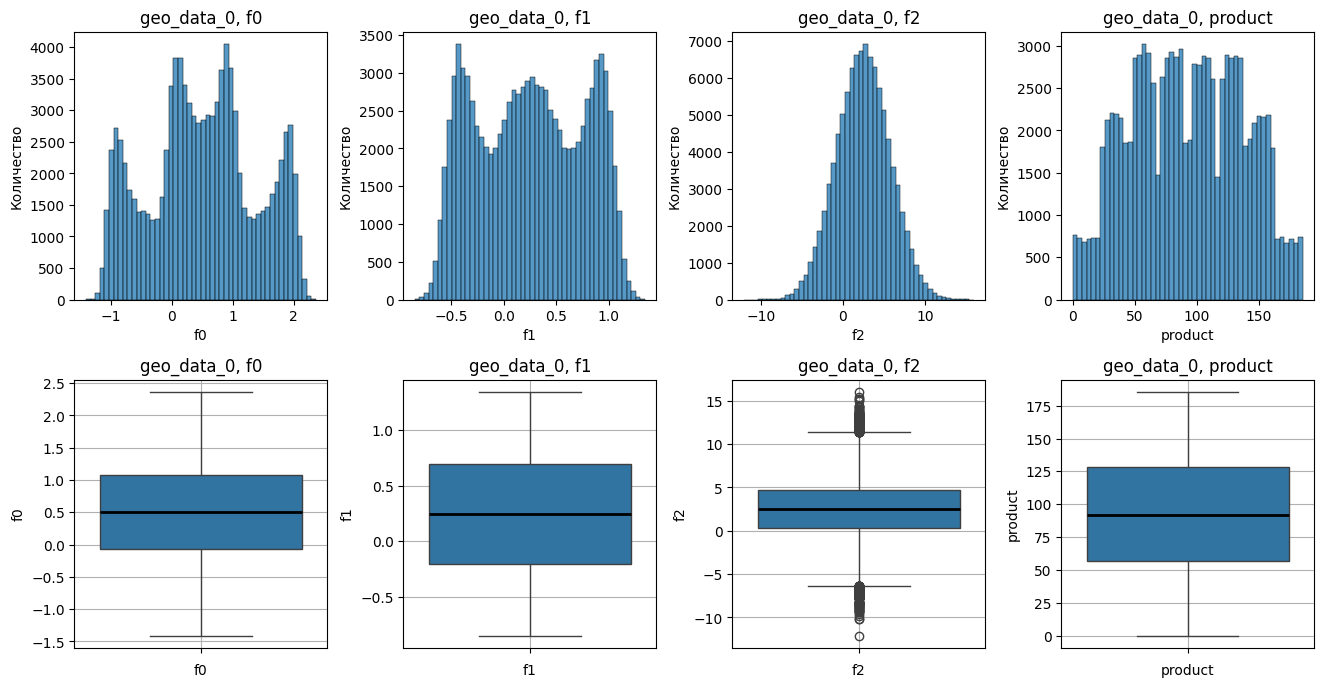

In [67]:
# построим графики для каждого региона
columns = ['f0', 'f1', 'f2', 'product']

plt.figure(figsize=(16,8))

i=1
for column in columns:
    # построим столбчатую диаграмму
    plt.subplot(2, 4, i)
    sns.histplot(data=geo_data_0[[column]], x=column, bins=50, legend='')
    plt.title(f'geo_data_0, {column}')
    plt.xlabel(column)
    plt.ylabel('Количество')
    plt.subplots_adjust(hspace=0.3)
    plt.subplots_adjust(wspace=0.3)

    # построим диаграмму размаха
    plt.subplot(2, 4, i+4)
    sns.boxplot(geo_data_0[column], medianprops={"color": "black", "linewidth": 2})
    plt.title(f'geo_data_0, {column}')
    plt.grid(visible=True)
    plt.xlabel(column)

    i+=1

In [68]:
# получим описание данных
geo_data_0[columns].describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.500419,0.250143,2.502647,92.500000
std,0.871832,0.504433,3.248248,44.288691
min,-1.408605,-0.848218,-12.088328,0.000000
25%,-0.072580,-0.200881,0.287748,56.497507
50%,0.502360,0.250252,2.515969,91.849972
75%,1.073581,0.700646,4.715088,128.564089
max,2.362331,1.343769,16.003790,185.364347


**Вывод:**

Для региона 0 нормальное распределение характерно только для признака f2. 

При этом для данного признака выявлены выбросы, не требующие удаления, т.к. это просто хвосты распределения, о чём можно судить потому что они лежат достаточно близко к "усам", и весьма большими количествами.

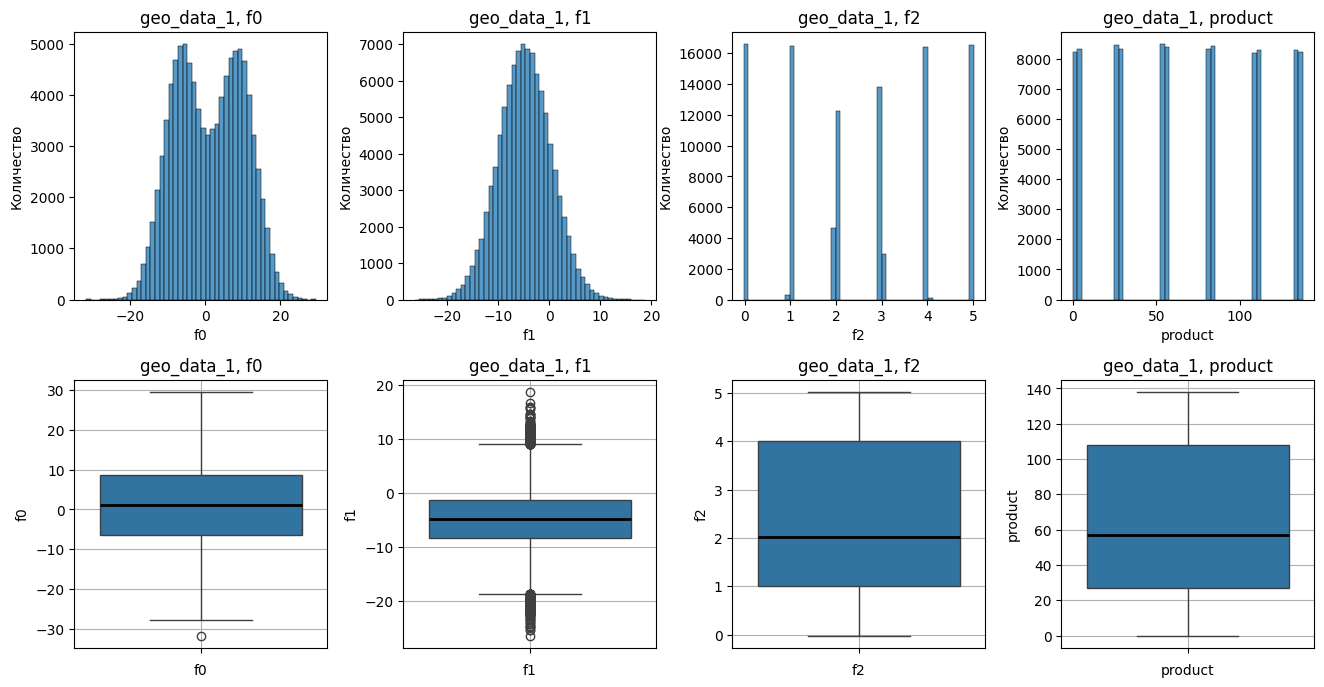

In [69]:
plt.figure(figsize=(16,8))

i=1
for column in columns:
    # построим столбчатую диаграмму
    plt.subplot(2, 4, i)
    sns.histplot(data=geo_data_1[[column]], x=column, bins=50, legend='')
    plt.title(f'geo_data_1, {column}')
    plt.xlabel(column)
    plt.ylabel('Количество')
    plt.subplots_adjust(hspace=0.3)
    plt.subplots_adjust(wspace=0.3)

    # построим диаграмму размаха
    plt.subplot(2, 4, i+4)
    sns.boxplot(geo_data_1[column], medianprops={"color": "black", "linewidth": 2})
    plt.title(f'geo_data_1, {column}')
    plt.grid(visible=True)
    plt.xlabel(column)

    i+=1

In [70]:
# получим описание данных
geo_data_1[columns].describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.141296,-4.796579,2.494541,68.825000
std,8.965932,5.119872,1.703572,45.944423
min,-31.609576,-26.358598,-0.018144,0.000000
25%,-6.298551,-8.267985,1.000021,26.953261
50%,1.153055,-4.813172,2.011479,57.085625
75%,8.621015,-1.332816,3.999904,107.813044
max,29.421755,18.734063,5.019721,137.945408


**Вывод:**

Для региона 1 нормальное распределение характерно только для признака f1. 

При этом для данного признака выявлены выбросы, не требующие удаления, т.к. это просто хвосты распределения, о чём можно судить потому что они лежат достаточно близко к "усам", и весьма большими количествами.

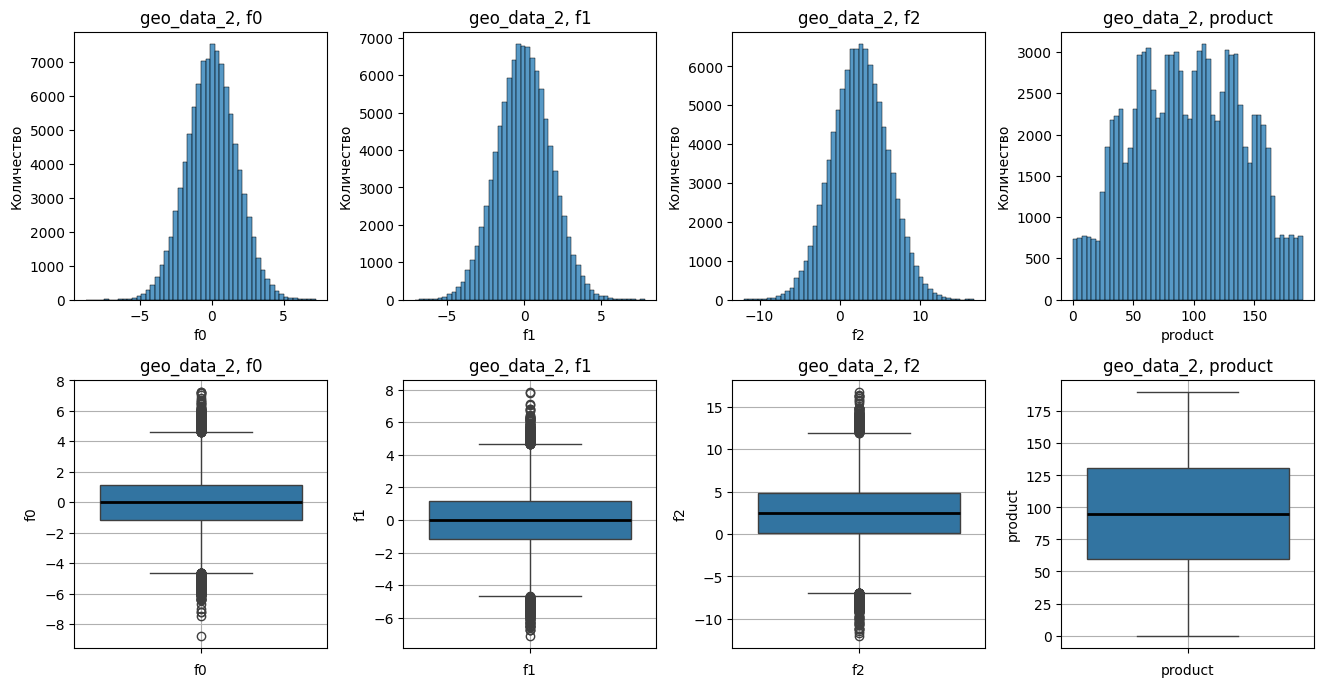

In [71]:
plt.figure(figsize=(16,8))

i=1
for column in columns:
    # построим столбчатую диаграмму
    plt.subplot(2, 4, i)
    sns.histplot(data=geo_data_2[[column]], x=column, bins=50, legend='')
    plt.title(f'geo_data_2, {column}')
    plt.xlabel(column)
    plt.ylabel('Количество')
    plt.subplots_adjust(hspace=0.3)
    plt.subplots_adjust(wspace=0.3)

    # построим диаграмму размаха
    plt.subplot(2, 4, i+4)
    sns.boxplot(geo_data_2[column], medianprops={"color": "black", "linewidth": 2})
    plt.title(f'geo_data_2, {column}')
    plt.grid(visible=True)
    plt.xlabel(column)

    i+=1

In [72]:
# получим описание данных
geo_data_2[columns].describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.002023,-0.002081,2.495128,95.000000
std,1.732045,1.730417,3.473445,44.749921
min,-8.760004,-7.084020,-11.970335,0.000000
25%,-1.162288,-1.174820,0.130359,59.450441
50%,0.009424,-0.009482,2.484236,94.925613
75%,1.158535,1.163678,4.858794,130.595027
max,7.238262,7.844801,16.739402,190.029838


**Вывод:**

Для региона 2 нормальное распределение характерно для признаков f0, f1, f2. 

При этом для данных признаков выявлены выбросы, не требующие удаления, т.к. это просто хвосты распределения, о чём можно судить потому что они лежат достаточно близко к "усам", и весьма большими количествами

#### Вывод по результатам исследовательского анализа данных

Были проанализированы признаки для каждого региона. 

Распределение признаков по своим свойствам отличается в зависимости от региона. 

Учитывая распределения можно сделать вывод о синтетической природе данных. 

## Корреляционный анализ данных

Т.к. мы планируем обучить линейную модель, стоит убедиться в том, что в данных нет мультиколлинеарности. Выполним корреляционный анализ.

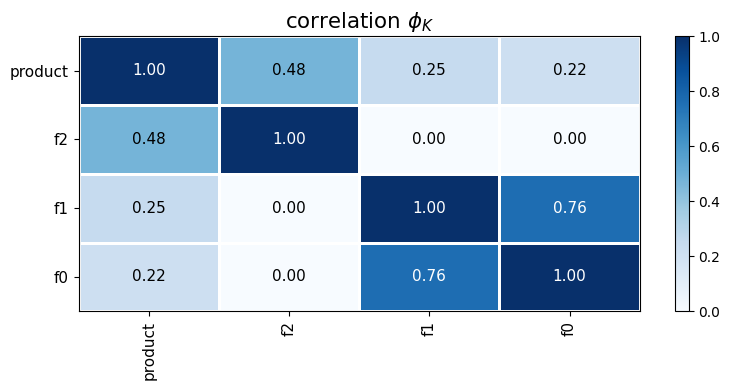

In [73]:
interval_cols = ['f0',
                 'f1',
                 'f2', 
                 'product'
]

phik_overview = phik_matrix(geo_data_0, interval_cols=interval_cols)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Blues',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.1,
    figsize=(8, 4)
);

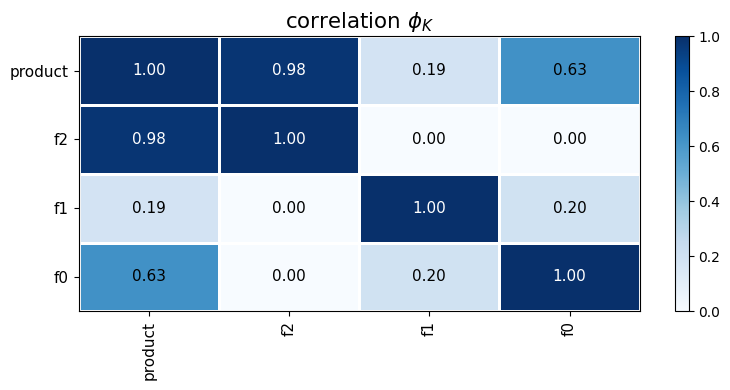

In [74]:
interval_cols = ['f0',
                 'f1',
                 'f2', 
                 'product'
]

phik_overview = phik_matrix(geo_data_1, interval_cols=interval_cols)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Blues',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.1,
    figsize=(8, 4)
);

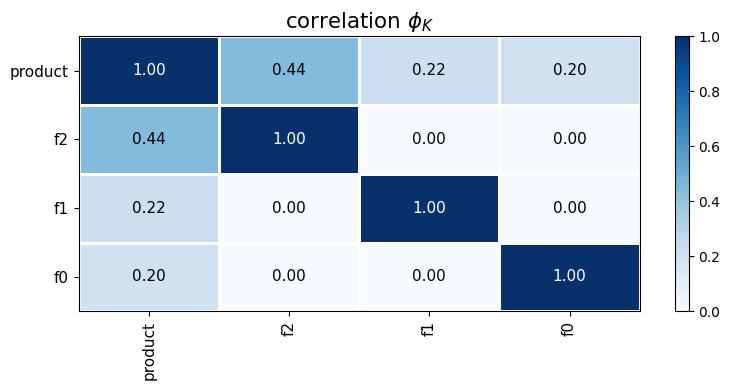

In [75]:
interval_cols = ['f0',
                 'f1',
                 'f2', 
                 'product'
]

phik_overview = phik_matrix(geo_data_2, interval_cols=interval_cols)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Blues',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.1,
    figsize=(8, 4)
);

### Вывод по результатам корреляционного анализа данных 

По результатам корреляционного анализа можно сделать вывод, что:
- для данных 0: выявлен высокий уровень корреляции между признаками f1 и f0;
- для данных 1: выявлен весьма высокий уровень корреляции между признаками f2 и product, высокий уровень корреляции между f0 и product;
- для данных 2: выявлен умеренный уровень корреляции между признаками f2 и product.

## Обучение и проверка модели

In [76]:
# сформируем список колонок для масштабирования
num_columns = ['f0', 'f1', 'f2']

In [77]:
# создадим функцию для обучения модели
def learning_model_function(df, target):
    # разобьем данные на обучающую и валидационную выборки в соотношении 75:25
    X = df.drop(target, axis=1)
    y = df[target]

    X_train, X_test_valid, y_train, y_test_valid = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

    # выбор способа масштабирования
    scaler = StandardScaler()

    # настройка и масштабирование тренировочной выборки
    X_train_scaled = scaler.fit_transform(X_train[num_columns])

    # масштабирование тестовой выборки
    X_test_valid_scaled = scaler.transform(X_test_valid[num_columns]) 

    # создадим и обучим модель
    model_lr = LinearRegression() 

    model_lr.fit(X_train_scaled, y_train) 

    y_pred = model_lr.predict(X_test_valid_scaled)

    return y_test_valid, y_pred

### geo_data_0

In [78]:
y_test_valid, y_pred = learning_model_function(geo_data_0, 'product')

In [79]:
# сохраним предсказания и правильные ответы на валидационной выборке
pred_geo_0 = pd.DataFrame()
pred_geo_0['y_test_valid'] = y_test_valid
pred_geo_0['y_pred'] = y_pred

# выведем средний запас предсказанного сырья
pred_geo_0.describe()

,y_test_valid,y_pred
count,25000.000000,25000.000000
mean,92.325956,92.398800
std,44.277512,23.217563
min,0.021781,-9.836371
25%,56.300099,76.788865
50%,90.785176,92.414871
75%,128.117571,108.036487
max,185.355615,176.536104


In [80]:
# посчитаем метрики для линейной регрессии
try:
    rmse = mean_squared_error(y_test_valid, y_pred, squared=False) 
except:
    rmse = root_mean_squared_error(y_test_valid, y_pred)

print(f'RMSE = {rmse:.2f}')

RMSE = 37.76


In [81]:
# добавим данные в отдельный датафрейм
pred_mean =pd.DataFrame()
pred_mean['parametr'] = ['mean', 'rmse']
pred_mean['0'] = [pred_geo_0['y_pred'].mean(), rmse]

**Вывод:**

Для региона 0 в результате обучения модели получили значение RMSE ~ 37.76. 

Средние значения реальных и предсказанных данных составляют ~ 92.3. Медианные значения также располагаются близко друг к другу. 

### geo_data_1

In [82]:
y_test_valid, y_pred = learning_model_function(geo_data_1, 'product')

In [83]:
# сохраним предсказания и правильные ответы на валидационной выборке
pred_geo_1 = pd.DataFrame()
pred_geo_1['y_test_valid'] = y_test_valid
pred_geo_1['y_pred'] = y_pred

# выведем средний запас предсказанного сырья
pred_geo_1.describe()

,y_test_valid,y_pred
count,25000.000000,25000.000000
mean,68.725381,68.712878
std,45.945586,45.946672
min,0.000000,-2.070621
25%,30.132364,28.578501
50%,57.085625,57.918041
75%,107.813044,109.313612
max,137.945408,139.983277


In [84]:
# посчитаем метрики для линейной регрессии
try:
    rmse = mean_squared_error(y_test_valid, y_pred, squared=False) 
except:
    rmse = root_mean_squared_error(y_test_valid, y_pred)

pred_mean['1'] = [pred_geo_1['y_pred'].mean(), rmse]

print(f'RMSE = {rmse:.2f}')

RMSE = 0.89


**Вывод:**

Для региона 1 в результате обучения модели получили значение RMSE ~ 0.89. 

Средние значения реальных и предсказанных данных составляют ~68.7. Медианные значения также располагаются близко друг к другу. 

### geo_data_2

In [85]:
y_test_valid, y_pred = learning_model_function(geo_data_2, 'product')

In [86]:
# сохраним предсказания и правильные ответы на валидационной выборке
pred_geo_2 = pd.DataFrame()
pred_geo_2['y_test_valid'] = y_test_valid
pred_geo_2['y_pred'] = y_pred

# выведем средний запас предсказанного сырья
pred_geo_2.describe()

,y_test_valid,y_pred
count,25000.000000,25000.000000
mean,95.150999,94.771024
std,44.783220,19.927375
min,0.019327,16.196849
25%,59.666842,81.157678
50%,94.936982,94.612618
75%,130.566313,108.357649
max,190.011722,170.529209


In [87]:
# посчитаем метрики для линейной регрессии
try:
    rmse = mean_squared_error(y_test_valid, y_pred, squared=False) 
except:
    rmse = root_mean_squared_error(y_test_valid, y_pred)

pred_mean['2'] = [pred_geo_2['y_pred'].mean(), rmse]

print(f'RMSE = {rmse:.2f}')

RMSE = 40.15


**Вывод:**

Для региона 2 в результате обучения модели получили значение RMSE ~ 40.15. 

Средние значения реальных и предсказанных данных составляют ~ 95. Медианные значения также располагаются близко друг к другу. 

### Вывод по результатам обучения моделей

Были получены следующие значения RMSE:
- 0 - 37.76
- 1 - 0.89
- 2 - 40.15

Можно сделать вывод о том, что лучше всего предсказывает модель, обученная для региона 1. 

Для регионов 0 и 2 корень из среднеквадратичной ошибки ~40, что можно заметить на данных ниже и выше медианы. 

## Подготовка к расчету прибыли

In [88]:
# сохраним ключевые значения для расчетов

# при разведке региона исследуют 500 точек
WELL_COUNT = 500

# для разработки выбирают 200 лучших
WELL_BEST_COUNT = 200

# бюджет на разработку скважин в регионе
BUDGET = 10000000000

# доход с каждой единицы продукта
ONE_BARREL_INCOME = 450000

# приемлемая вероятность убытков
STOP_LOSS = 0.025

# количество выборок для бутстрэпа
BOOTSTRAP_SAMPLES = 1000

In [89]:
# рассчитаем достаточный объём сырья для безубыточной разработки новой скважины
min_barrel_count = (BUDGET/WELL_BEST_COUNT)/ONE_BARREL_INCOME

print(f'Количество сырья для безубыточного производства - {min_barrel_count:.2f} тыс. баррелей')

Количество сырья для безубыточного производства - 111.11 тыс. баррелей


In [90]:
# посчитаем разницу между количеством сырья для безубыточного производства и средним значением для каждого региона
pred_mean.loc[2] = ['difference_bw_mean_min',
                    float(pred_mean[pred_mean['parametr'] == 'mean']['0'] - min_barrel_count), 
                    float(pred_mean[pred_mean['parametr'] == 'mean']['1'] - min_barrel_count),
                    float(pred_mean[pred_mean['parametr'] == 'mean']['2'] - min_barrel_count)]
pred_mean

,parametr,0,1,2
0,mean,92.398800,68.712878,94.771024
1,rmse,37.756600,0.890280,40.145872
2,difference_bw_mean_min,-18.712311,-42.398233,-16.340087


In [91]:
# напишем функцию для расчёта прибыли по выбранным скважинам и предсказаниям модели
def profit_calculation(df):
    revenue = df.sort_values(by='y_pred', ascending=False).head(WELL_BEST_COUNT)['y_test_valid'].sum() * ONE_BARREL_INCOME
    profit = revenue - BUDGET
    return profit

profit_0 = profit_calculation(pred_geo_0)
profit_1 = profit_calculation(pred_geo_1)
profit_2 = profit_calculation(pred_geo_2)

print(f'Прибыль для региона 0 - {locale.format_string("%0.2f", profit_0, grouping=True)} руб.')
print(f'Прибыль для региона 1 - {locale.format_string("%0.2f", profit_1, grouping=True)} руб.')
print(f'Прибыль для региона 2 - {locale.format_string("%0.2f", profit_2, grouping=True)} руб.')

Прибыль для региона 0 - 3 359 141 114,46 руб.
Прибыль для региона 1 - 2 415 086 696,68 руб.
Прибыль для региона 2 - 2 598 571 759,37 руб.


### Вывод по результатам подготовки к расчету прибыли

Было рассчитано, что количество сырья, которое необходимо получать для безубыточного производства составляет ~ 111 тыс. баррелей. 

Рассчитанные средние значения для регионов меньше указанного значения безубыточности. Необходимо очень внимательно отнестись к выбору разрабатываемых скважин. 

Была рассчитана прибыль от скважин с максимальными значениями предсказаний.

## Расчёт прибыли и рисков 

In [92]:
state = RandomState(12345)

def bootstrap_func(df):
    profits = []
    risk_count = 0
    for i in range(BOOTSTRAP_SAMPLES):
        subsample = df.sample(n=WELL_COUNT, replace=True, random_state=state)

        subsample_profit = profit_calculation(subsample)
        profits.append(subsample_profit)

        if subsample_profit < 0:
            risk_count+=1

    profits = pd.Series(profits)
    
    # найдем среднюю прибыль
    mean_profit = profits.mean()
    
    # найдем 95%-й доверительный интервал
    lower = profits.quantile(0.025)
    upper = profits.quantile(0.975)

    # найдем риск убытков
    risk = risk_count/1000

    return profits,  mean_profit, lower, upper, risk

In [93]:
profits, mean_profit, lower, upper, risk = bootstrap_func(pred_geo_0)
print(f'Средняя прибыль для региона 0: {locale.format_string("%0.2f", mean_profit, grouping=True)} руб.')
print(f'Начало 95%-го доверительного интервала: {locale.format_string("%0.2f", lower, grouping=True)} руб.')
print(f'Конец 95%-го доверительного интервала: {locale.format_string("%0.2f", upper, grouping=True)} руб.')
print(f'Риск убытков для региона 0: {risk*100:.2f}%')

Средняя прибыль для региона 0: 406 278 783,42 руб.
Начало 95%-го доверительного интервала: -117 742 136,49 руб.
Конец 95%-го доверительного интервала: 911 737 050,75 руб.
Риск убытков для региона 0: 6.70%


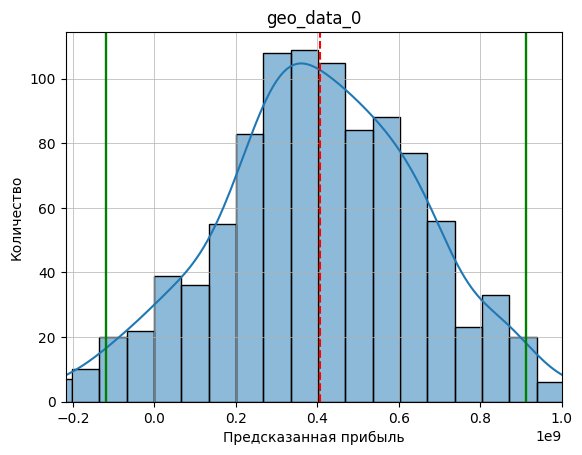

In [94]:
fig, ax = plt.subplots()
sns.histplot(profits, kde=True)
plt.axvline(mean_profit, color='r', linestyle='dashed')
plt.axvline(lower, color='g', lw=1.7)
plt.axvline(upper, color='g', lw=1.7)
plt.title(f'geo_data_0')
plt.xlabel('Предсказанная прибыль')
plt.ylabel('Количество')
plt.grid(visible=True, lw=0.5)
plt.xlim(lower-100000000, 1000000000);

In [95]:
profits, mean_profit, lower, upper, risk = bootstrap_func(pred_geo_1)
print(f'Средняя прибыль для региона 1: {locale.format_string("%0.2f", mean_profit, grouping=True)} руб.')
print(f'Начало 95%-го доверительного интервала: {locale.format_string("%0.2f", lower, grouping=True)} руб.')
print(f'Конец 95%-го доверительного интервала: {locale.format_string("%0.2f", upper, grouping=True)} руб.')
print(f'Риск убытков для региона 1: {risk*100:.2f}%')

Средняя прибыль для региона 1: 441 504 277,59 руб.
Начало 95%-го доверительного интервала: 35 728 489,28 руб.
Конец 95%-го доверительного интервала: 828 006 639,00 руб.
Риск убытков для региона 1: 1.60%


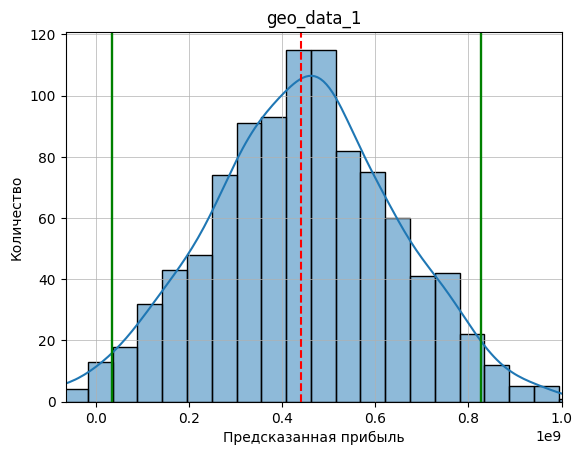

In [96]:
fig, ax = plt.subplots()
sns.histplot(profits, kde=True)
plt.axvline(mean_profit, color='r', linestyle='dashed')
plt.axvline(lower, color='g', lw=1.7)
plt.axvline(upper, color='g', lw=1.7)
plt.title(f'geo_data_1')
plt.xlabel('Предсказанная прибыль')
plt.ylabel('Количество')
plt.grid(visible=True, lw=0.5)
plt.xlim(lower-100000000, 1000000000);

In [97]:
profits, mean_profit, lower, upper, risk = bootstrap_func(pred_geo_2)
print(f'Средняя прибыль для региона 2: {locale.format_string("%0.2f", mean_profit, grouping=True)} руб.')
print(f'Начало 95%-го доверительного интервала: {locale.format_string("%0.2f", lower, grouping=True)} руб.')
print(f'Конец 95%-го доверительного интервала: {locale.format_string("%0.2f", upper, grouping=True)} руб.')
print(f'Риск убытков для региона 2: {risk*100:.2f}%')

Средняя прибыль для региона 2: 385 213 195,91 руб.
Начало 95%-го доверительного интервала: -164 785 166,11 руб.
Конец 95%-го доверительного интервала: 888 206 234,20 руб.
Риск убытков для региона 2: 7.80%


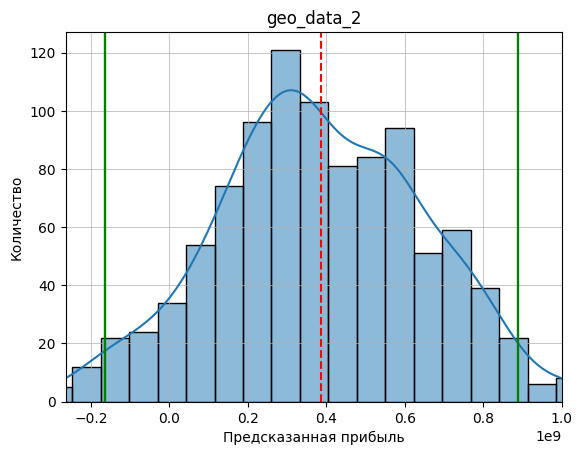

In [98]:
fig, ax = plt.subplots()
sns.histplot(profits, kde=True)
plt.axvline(mean_profit, color='r', linestyle='dashed')

plt.axvline(lower, color='g', lw=1.7)
plt.axvline(upper, color='g', lw=1.7)
plt.title(f'geo_data_2')
plt.xlabel('Предсказанная прибыль')
plt.ylabel('Количество')
plt.grid(visible=True, lw=0.5)
plt.xlim(lower-100000000, 1000000000);

### Вывод по результатам расчета прибыли и убытков

**Предлагается использовать регион 1 для разработки скважин.**

По результатам использования бустрепа было выявлено, что приемлемый риск убытков актуален только для региона 1. 

Для региона 0 и 2 риск убытков составляет 6.6%.  и 10.1%, соответственно. 

Начало 95%-го доверительного интервала для региона 1 - положительное значение, в отличие от регионов 0 и 2. 

## Общий вывод

1. Были загружены данные. В качестве их подготовки были заменены идентификаторы датафреймов на значения из столбцов `id`. 
2. Был проанализированы признаки для каждого региона и удалены выбросы в признаках. 
Распределение признаков по своим свойствам отличается в зависимости от региона. 
3. По результатам обучения и проверки моделей было выявлено, что лучше всего предсказывает модель, обученная для региона 1.
4. Было рассчитано, что количество сырья, которое необходимо получать для безубыточного производства составляет ~ 111 тыс. баррелей. 
5. Риск убытков менее 2,5% - только у региона 1. 
Для 95% выборок скважин региона 1 характерна прибыль (а не убытки). 